# GS_GMLIP Tutorial: Global Structure Search on Cu(111)

This notebook demonstrates the core workflow of **GS_GMLIP** — building a slab,
defining adsorbate building blocks, running **Genetic Algorithm (GA)** and
**Grand Canonical Monte Carlo (GCMC)** searches, and analyzing the results.

We use ASE's EMT calculator for fast demonstration. Replace with `MACEEvaluator`
for production runs.

## Table of Contents
1. [Setup & Imports](#1-setup--imports)
2. [Build a Cu(111) Slab](#2-build-a-cu111-slab)
3. [Define Search Region & Building Blocks](#3-define-search-region--building-blocks)
4. [Set Up the Evaluator](#4-set-up-the-evaluator)
5. [Run Genetic Algorithm (GA)](#5-run-genetic-algorithm-ga)
6. [Run Grand Canonical Monte Carlo (GCMC)](#6-run-grand-canonical-monte-carlo-gcmc)
7. [Analyze & Compare Results](#7-analyze--compare-results)
8. [Visualize Structures](#8-visualize-structures)

## 1. Setup & Imports

Import the key modules from `gs_gmlip` along with ASE for atomic structure manipulation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ase import Atoms
from ase.build import fcc111
from ase.calculators.emt import EMT
from ase.constraints import FixAtoms
from ase.visualize.plot import plot_atoms

# GS_GMLIP modules
from gs_gmlip.structure.atoms import SlabAtoms
from gs_gmlip.structure.region import BoxRegion
from gs_gmlip.structure.bonds import BondData, generate_blmin, get_bond_matrix
from gs_gmlip.structure.composition import (
    MolecularBlock, CompositionConstraint,
    hydrogen_block, oxygen_block,
)
from gs_gmlip.evaluate.mlip.ase_calc import ASECalculatorEvaluator
from gs_gmlip.search.ga.startgenerator import StartGenerator
from gs_gmlip.search.gcmc.ensemble import GCEnsemble
from gs_gmlip.search.gcmc.moves import InsertMove, DeleteMove, DisplaceMove
from gs_gmlip.analysis.structure import StructureAnalyzer, pair_distribution, fingerprint_distance
from gs_gmlip.analysis.trajectory import TrajectoryAnalyzer

print("All imports successful!")

All imports successful!


## 2. Build a Cu(111) Slab

We create a 3×3 Cu(111) slab with 3 layers, wrap it into `SlabAtoms`,
and tag the bottom layer as fixed substrate (tag=0) and the top layers as active (tag=1).

In [2]:
# Build a Cu(111) slab with 3 layers and 10 Å vacuum
slab_ase = fcc111("Cu", size=(3, 3, 3), vacuum=10.0, periodic=True)

# Convert to SlabAtoms
slab = SlabAtoms.from_atoms(slab_ase)

# Tag atoms: below the mid-height are slab (tag=0), above are active (tag=1)
z_positions = slab.positions[:, 2]
z_sorted = sorted(set(z_positions.round(2)))
# Fix the bottom layer
z_threshold = z_sorted[0] + 0.5  # just above the first layer
slab.tag_slab_by_height(z_threshold=z_sorted[1] + 0.5)
slab.set_slab_constraints()

print(f"Slab: {slab.get_chemical_formula()}")
print(f"Total atoms: {len(slab)}")
print(f"Slab atoms (tag=0): {slab.n_slab}")
print(f"Active atoms (tag>0): {slab.n_active}")
print(f"Cell: {slab.cell.lengths()}")
print(f"Unique z-layers: {z_sorted}")

Slab: Cu27
Total atoms: 27
Slab atoms (tag=0): 18
Active atoms (tag>0): 9
Cell: [ 7.65796644  7.65796644 24.16846894]
Unique z-layers: [np.float64(10.0), np.float64(12.08), np.float64(14.17)]


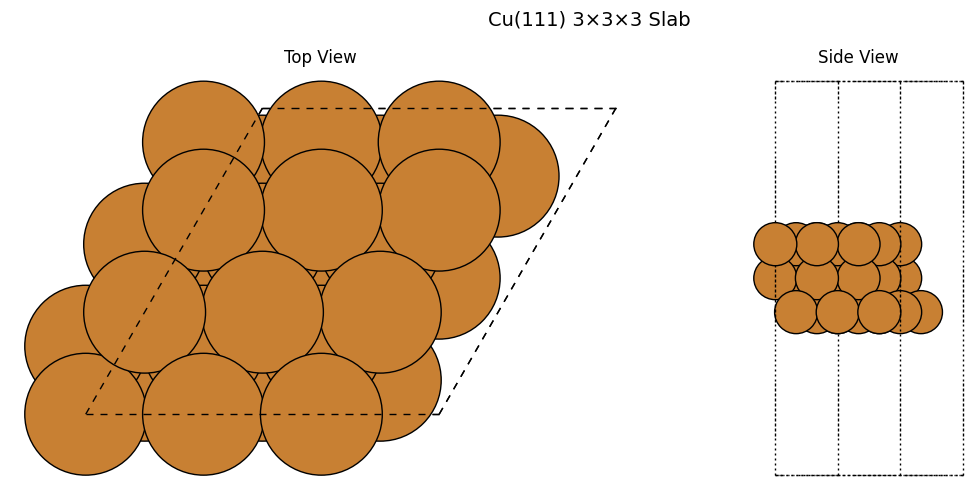

In [3]:
# Visualize the slab from the side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_atoms(slab, axes[0], rotation="0x,0y,0z")
axes[0].set_title("Top View")

plot_atoms(slab, axes[1], rotation="-90x,0y,0z")
axes[1].set_title("Side View")

plt.suptitle("Cu(111) 3×3×3 Slab", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Define Search Region & Building Blocks

The **search region** is a box above the slab surface where adsorbates can be placed.
**Building blocks** define what molecular species to insert (H, O atoms here for simplicity with EMT).

Slab top z = 14.17 Å
Search region: z = [15.67, 20.17] Å


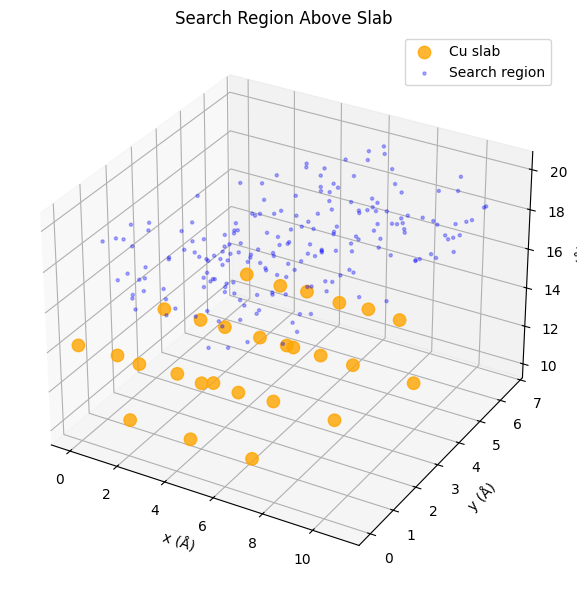

In [4]:
# Define the insertion region: a box 1.5–6.0 Å above the slab top
z_top = slab.positions[:, 2].max()
region = BoxRegion(
    cell=slab.cell,
    z_min=z_top + 1.5,
    z_max=z_top + 6.0,
    pbc=slab.pbc,
)

print(f"Slab top z = {z_top:.2f} Å")
print(f"Search region: z = [{region.z_min:.2f}, {region.z_max:.2f}] Å")

# Visualize the search region by sampling random points
rng = np.random.default_rng(42)
sample_points = region.random_positions(200, rng)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(*slab.positions.T, c="orange", s=80, label="Cu slab", alpha=0.8)
ax.scatter(*sample_points.T, c="blue", s=5, alpha=0.3, label="Search region")
ax.set_xlabel("x (Å)"); ax.set_ylabel("y (Å)"); ax.set_zlabel("z (Å)")
ax.legend()
ax.set_title("Search Region Above Slab")
plt.tight_layout()
plt.show()

In [5]:
# Define building blocks (single atoms for EMT compatibility)
h_block = hydrogen_block(mu=-3.4)   # H atom, chemical potential = -3.4 eV
o_block = oxygen_block(mu=-4.5)     # O atom, chemical potential = -4.5 eV

blocks = [h_block, o_block]

for b in blocks:
    print(f"Block: {b.name}, n_atoms={b.n_atoms}, μ={b.chemical_potential} eV")

# Generate minimum interatomic distance constraints
blmin = generate_blmin(["Cu", "H", "O"], scale=0.7)
print(f"\nMinimum distance pairs: {len(blmin)}")
for (z1, z2), d in sorted(blmin.items()):
    if z1 <= z2:
        from ase.data import chemical_symbols
        print(f"  {chemical_symbols[z1]}-{chemical_symbols[z2]}: {d:.3f} Å")

Block: H, n_atoms=1, μ=-3.4 eV
Block: O, n_atoms=1, μ=-4.5 eV

Minimum distance pairs: 9
  H-H: 0.434 Å
  H-O: 0.679 Å
  H-Cu: 1.141 Å
  O-O: 0.924 Å
  O-Cu: 1.386 Å
  Cu-Cu: 1.848 Å


## 4. Set Up the Evaluator

An **evaluator** wraps a calculator to provide `evaluate()` and `relax()` methods.
Here we use EMT for speed. For real catalysis work, use `MACEEvaluator`.

In [6]:
# Create an evaluator using ASE's EMT calculator
evaluator = ASECalculatorEvaluator(calculator=EMT())

# Test: evaluate the bare slab
slab_eval = evaluator.evaluate(slab.copy())
print(f"Bare slab energy: {slab_eval.get_potential_energy():.4f} eV")

# Test: evaluate and relax
slab_relaxed = evaluator.evaluate(slab.copy(), relax=True, fmax=0.05, steps=100)
print(f"Relaxed slab energy: {slab_relaxed.get_potential_energy():.4f} eV")

Bare slab energy: 6.4209 eV
Relaxed slab energy: 6.4057 eV


## 5. Run Genetic Algorithm (GA)

The GA workflow:
1. Generate random initial candidates using `StartGenerator`
2. Evaluate (relax) each candidate
3. Select parents → crossover/mutation → evaluate offspring → update population

Here we manually step through the GA components for educational purposes.
In production, use `GARunner` which orchestrates all this automatically.

In [7]:
# Step 5a: Generate random initial candidates
rng = np.random.default_rng(42)

gen = StartGenerator(
    slab=slab,
    blocks=blocks,
    counts=[2, 1],        # 2 H atoms + 1 O atom per candidate
    blmin=blmin,
    region=region,
    rng=rng,
)

# Generate 10 random candidates
n_candidates = 10
candidates = []
energies = []

print("Generating and evaluating initial candidates...")
for i in range(n_candidates):
    cand = gen.get_new_candidate()
    if cand is not None:
        # Relax the candidate
        relaxed = evaluator.evaluate(cand, relax=True, fmax=0.1, steps=50)
        e = relaxed.get_potential_energy()
        candidates.append(relaxed)
        energies.append(e)
        print(f"  Candidate {i+1}: {relaxed.get_chemical_formula():>12s}  E = {e:8.4f} eV")

print(f"\nGenerated {len(candidates)} valid candidates")
print(f"Best energy: {min(energies):.4f} eV")
print(f"Worst energy: {max(energies):.4f} eV")

Generating and evaluating initial candidates...
  Candidate 1:      H2Cu27O  E =  12.8029 eV
  Candidate 2:      H2Cu27O  E =   9.6538 eV
  Candidate 3:      H2Cu27O  E =  12.8141 eV
  Candidate 4:      H2Cu27O  E =   9.6695 eV
  Candidate 5:      H2Cu27O  E =   8.6346 eV
  Candidate 6:      H2Cu27O  E =   6.5145 eV
  Candidate 7:      H2Cu27O  E =   7.5563 eV
  Candidate 8:      H2Cu27O  E =   6.5617 eV
  Candidate 9:      H2Cu27O  E =   6.5568 eV
  Candidate 10:      H2Cu27O  E =   9.6323 eV

Generated 10 valid candidates
Best energy: 6.5145 eV
Worst energy: 12.8141 eV


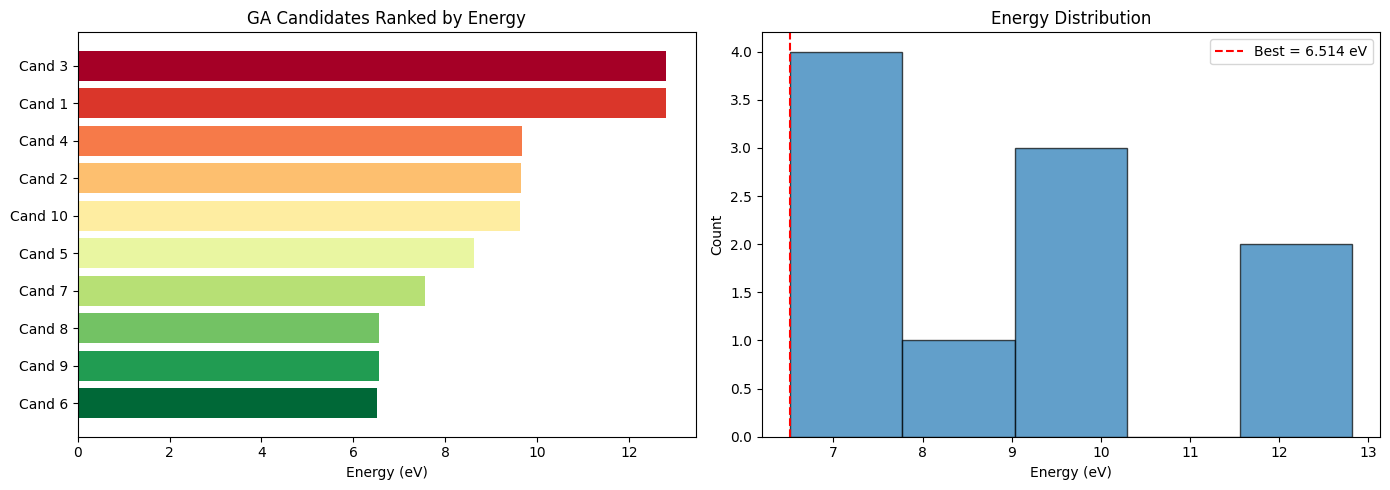

In [8]:
# Step 5b: Visualize energy distribution of GA candidates
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Energy bar chart
sorted_idx = np.argsort(energies)
colors = plt.cm.RdYlGn_r(np.linspace(0, 1, len(energies)))
axes[0].barh(range(len(energies)), [energies[i] for i in sorted_idx], color=[colors[j] for j in range(len(sorted_idx))])
axes[0].set_yticks(range(len(energies)))
axes[0].set_yticklabels([f"Cand {i+1}" for i in sorted_idx])
axes[0].set_xlabel("Energy (eV)")
axes[0].set_title("GA Candidates Ranked by Energy")

# Histogram
axes[1].hist(energies, bins=max(5, len(energies)//2), edgecolor="black", alpha=0.7)
axes[1].axvline(min(energies), color="red", linestyle="--", label=f"Best = {min(energies):.3f} eV")
axes[1].set_xlabel("Energy (eV)")
axes[1].set_ylabel("Count")
axes[1].set_title("Energy Distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

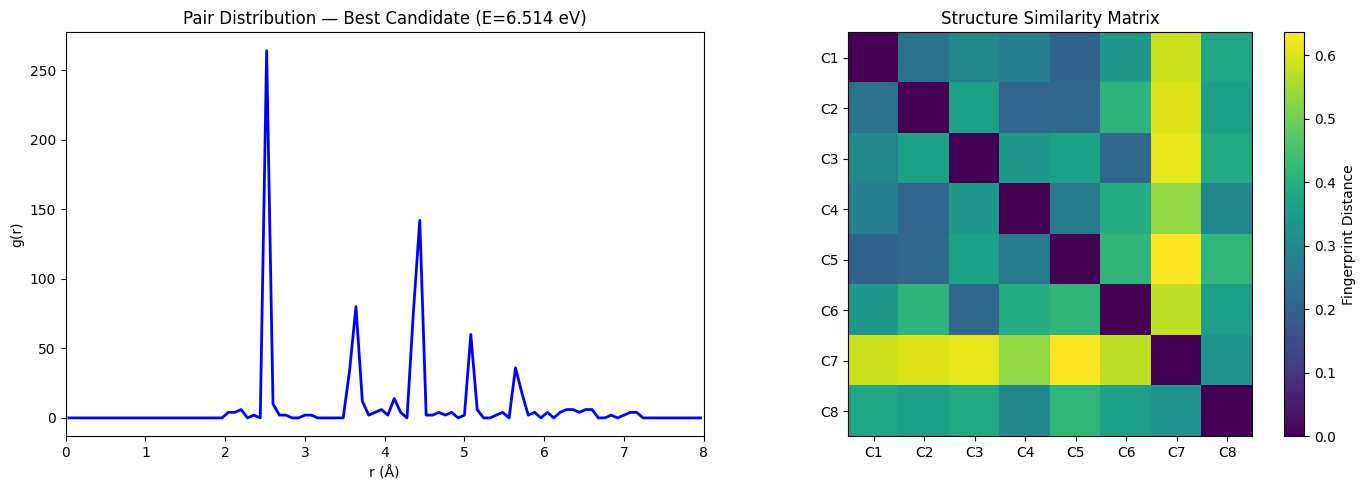

In [9]:
# Step 5c: Compare structures using pair distribution fingerprints
best_idx = np.argmin(energies)
best_struct = candidates[best_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pair distribution of the best structure
r, g = pair_distribution(best_struct, active_only=False)
axes[0].plot(r, g, "b-", lw=2)
axes[0].set_xlabel("r (Å)")
axes[0].set_ylabel("g(r)")
axes[0].set_title(f"Pair Distribution — Best Candidate (E={energies[best_idx]:.3f} eV)")
axes[0].set_xlim(0, 8)

# Fingerprint distance matrix
n = min(len(candidates), 8)
dist_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(i+1, n):
        d = fingerprint_distance(candidates[i], candidates[j])
        dist_matrix[i, j] = d
        dist_matrix[j, i] = d

im = axes[1].imshow(dist_matrix, cmap="viridis")
axes[1].set_xticks(range(n))
axes[1].set_yticks(range(n))
axes[1].set_xticklabels([f"C{i+1}" for i in range(n)])
axes[1].set_yticklabels([f"C{i+1}" for i in range(n)])
axes[1].set_title("Structure Similarity Matrix")
plt.colorbar(im, ax=axes[1], label="Fingerprint Distance")

plt.tight_layout()
plt.show()

## 6. Run Grand Canonical Monte Carlo (GCMC)

GCMC allows the **number of adsorbates to vary** during the search.
At each step, a random move is proposed:
- **Insert**: add a new adsorbate
- **Delete**: remove an existing adsorbate  
- **Displace**: move an adsorbate

Acceptance follows the grand canonical Metropolis criterion.

In [11]:
# Set up GCMC components manually
temperature = 600.0  # K
chemical_potentials = {"H": -3.4, "O": -4.5}

ensemble = GCEnsemble(
    temperature=temperature,
    chemical_potentials=chemical_potentials,
)

# Define moves
insert_move = InsertMove(blocks, region)
delete_move = DeleteMove(blocks)
displace_move = DisplaceMove(max_displacement=1.0)

moves = [insert_move, delete_move, displace_move]
move_probs = [0.4, 0.3, 0.3]

print(f"GCMC Setup:")
print(f"  Temperature: {temperature} K")
# print(f"  kT = {ensemble.kT:.4f} eV")
print(f"  Chemical potentials: {chemical_potentials}")
print(f"  Move types: {[type(m).__name__ for m in moves]}")
print(f"  Move probabilities: {move_probs}")

GCMC Setup:
  Temperature: 600.0 K
  Chemical potentials: {'H': -3.4, 'O': -4.5}
  Move types: ['InsertMove', 'DeleteMove', 'DisplaceMove']
  Move probabilities: [0.4, 0.3, 0.3]


In [12]:
# Run GCMC for 30 steps
rng = np.random.default_rng(123)

# Start from bare slab
current_atoms = slab.copy()
current_relaxed = evaluator.evaluate(current_atoms.copy(), relax=True, fmax=0.1, steps=50)
current_energy = current_relaxed.get_potential_energy()

best_energy = current_energy
best_atoms = current_relaxed.copy()
gcmc_trajectory = []
gcmc_structures = []

n_steps = 30
print(f"Starting GCMC with {n_steps} steps...")
print(f"Initial energy: {current_energy:.4f} eV")
print("-" * 70)

for step_i in range(n_steps):
    # Select a move
    move_idx = rng.choice(len(moves), p=move_probs)
    move = moves[move_idx]
    move_name = type(move).__name__
    
    # Propose
    new_atoms, log_ratio, move_info = move.propose(current_relaxed.copy(), rng)
    
    if new_atoms is None:
        gcmc_trajectory.append({
            "step": step_i, "energy": current_energy,
            "best_energy": best_energy, "accepted": False,
            "move": move_name, "n_atoms": len(current_relaxed),
        })
        continue
    
    # Evaluate
    try:
        new_relaxed = evaluator.evaluate(new_atoms, relax=True, fmax=0.1, steps=50)
        new_energy = new_relaxed.get_potential_energy()
    except Exception:
        gcmc_trajectory.append({
            "step": step_i, "energy": current_energy,
            "best_energy": best_energy, "accepted": False,
            "move": move_name, "n_atoms": len(current_relaxed),
        })
        continue
    
    # Accept/reject
    accepted = ensemble.accept(
        current_energy, new_energy, move_info, log_ratio, rng
    )
    
    if accepted:
        current_relaxed = new_relaxed
        current_energy = new_energy
        if new_energy < best_energy:
            best_energy = new_energy
            best_atoms = new_relaxed.copy()
    
    gcmc_trajectory.append({
        "step": step_i, "energy": current_energy,
        "best_energy": best_energy, "accepted": accepted,
        "move": move_name, "n_atoms": len(current_relaxed),
    })
    gcmc_structures.append(current_relaxed.copy())
    
    if step_i % 5 == 0:
        n_ads = sum(1 for t in current_relaxed.get_tags() if t > 0)
        status = "✓" if accepted else "✗"
        print(f"  Step {step_i:3d} | {move_name:>14s} | {status} | E={current_energy:8.4f} | best={best_energy:8.4f} | ads={n_ads}")

print("-" * 70)
print(f"GCMC done. Best energy: {best_energy:.4f} eV")
print(f"Final structure: {current_relaxed.get_chemical_formula()}")

Starting GCMC with 30 steps...
Initial energy: 6.4057 eV
----------------------------------------------------------------------
  Step   0 |     DeleteMove | ✓ | E=  6.4738 | best=  6.4057 | ads=0
  Step  20 |     InsertMove | ✗ | E=  6.4738 | best=  6.4057 | ads=0
----------------------------------------------------------------------
GCMC done. Best energy: 6.4057 eV
Final structure: Cu18


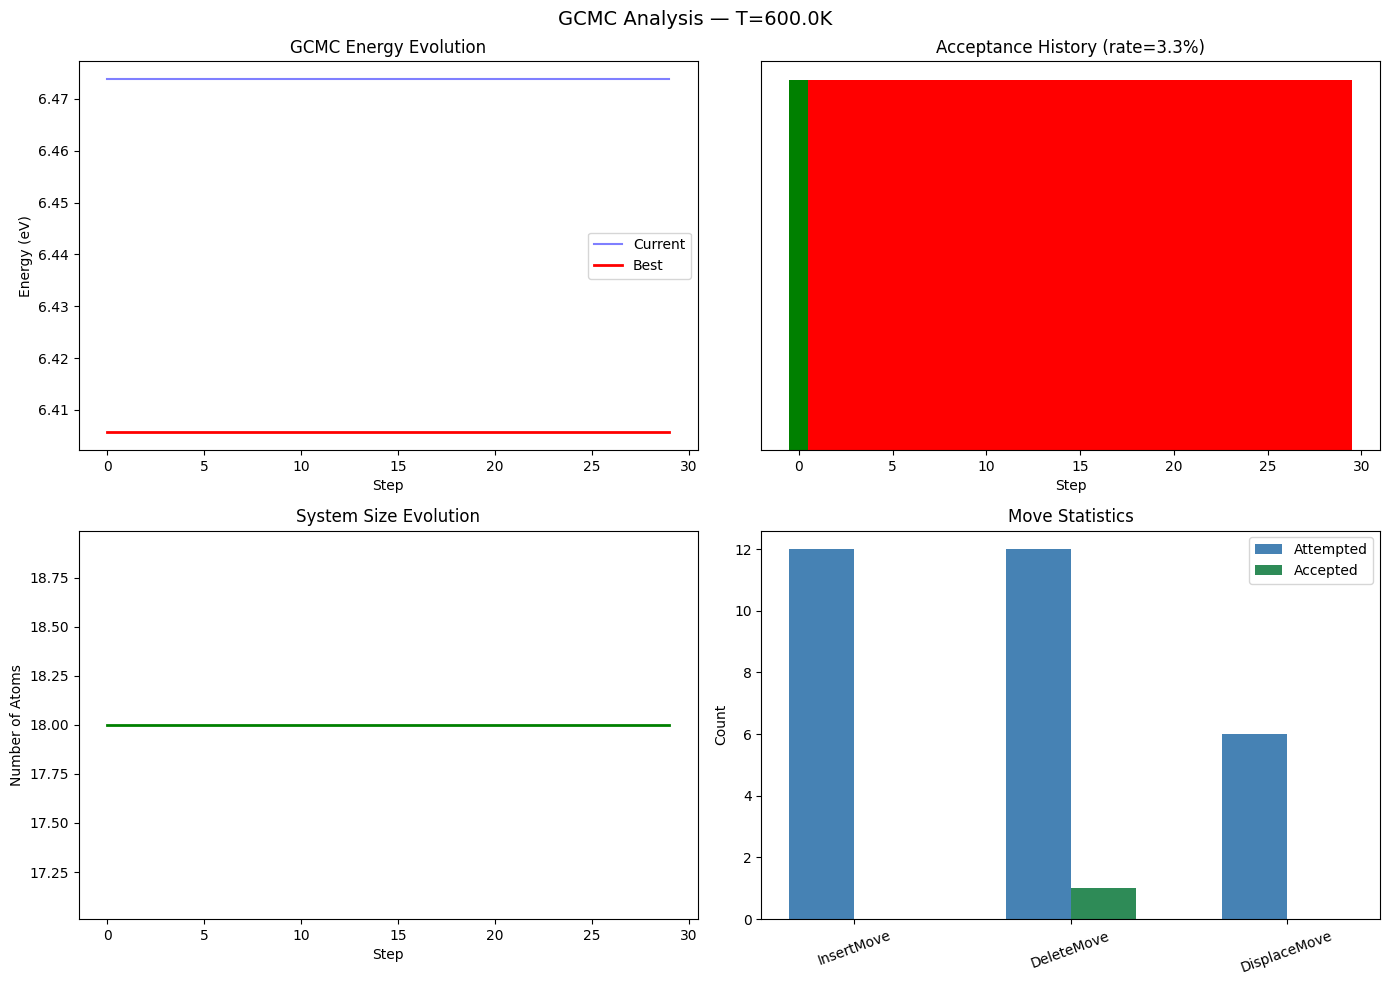

In [13]:
# Visualize GCMC trajectory
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

steps = [t["step"] for t in gcmc_trajectory]
traj_energies = [t["energy"] for t in gcmc_trajectory]
traj_best = [t["best_energy"] for t in gcmc_trajectory]
traj_accepted = [t["accepted"] for t in gcmc_trajectory]
traj_natoms = [t["n_atoms"] for t in gcmc_trajectory]

# Energy evolution
axes[0, 0].plot(steps, traj_energies, "b-", alpha=0.5, label="Current")
axes[0, 0].plot(steps, traj_best, "r-", lw=2, label="Best")
axes[0, 0].set_xlabel("Step")
axes[0, 0].set_ylabel("Energy (eV)")
axes[0, 0].set_title("GCMC Energy Evolution")
axes[0, 0].legend()

# Acceptance history
acc_colors = ["green" if a else "red" for a in traj_accepted]
axes[0, 1].bar(steps, [1]*len(steps), color=acc_colors, width=1.0)
axes[0, 1].set_xlabel("Step")
axes[0, 1].set_ylabel("")
axes[0, 1].set_title(f"Acceptance History (rate={np.mean(traj_accepted):.1%})")
axes[0, 1].set_yticks([])

# Number of atoms evolution
axes[1, 0].step(steps, traj_natoms, "g-", lw=2)
axes[1, 0].set_xlabel("Step")
axes[1, 0].set_ylabel("Number of Atoms")
axes[1, 0].set_title("System Size Evolution")

# Move type breakdown
move_types = [t["move"] for t in gcmc_trajectory]
unique_moves = list(set(move_types))
move_counts = [move_types.count(m) for m in unique_moves]
move_accepted = [sum(1 for t in gcmc_trajectory if t["move"] == m and t["accepted"]) for m in unique_moves]
x = np.arange(len(unique_moves))
axes[1, 1].bar(x - 0.15, move_counts, 0.3, label="Attempted", color="steelblue")
axes[1, 1].bar(x + 0.15, move_accepted, 0.3, label="Accepted", color="seagreen")
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(unique_moves, rotation=20)
axes[1, 1].set_ylabel("Count")
axes[1, 1].set_title("Move Statistics")
axes[1, 1].legend()

plt.suptitle(f"GCMC Analysis — T={temperature}K", fontsize=14)
plt.tight_layout()
plt.show()

## 7. Analyze & Compare Results

Use the `StructureAnalyzer` and `TrajectoryAnalyzer` to examine the search results.

In [14]:
# Analyze GA results with StructureAnalyzer
ga_analyzer = StructureAnalyzer(candidates, energies)

summary = ga_analyzer.energy_landscape_summary()
print("=== GA Energy Landscape Summary ===")
for k, v in summary.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")
    else:
        print(f"  {k}: {v}")

# Deduplicate structures
unique_indices = ga_analyzer.deduplicate(threshold=0.1)
print(f"\nUnique structures (threshold=0.1): {len(unique_indices)} / {len(candidates)}")

=== GA Energy Landscape Summary ===
  n_structures: 10
  energy_min: 6.5145
  energy_max: 12.8141
  energy_mean: 9.0396
  energy_std: 2.2490
  energy_range: 6.2996

Unique structures (threshold=0.1): 10 / 10


In [15]:
# Analyze GCMC trajectory
gcmc_analyzer = TrajectoryAnalyzer(gcmc_trajectory, gcmc_structures)

print("=== GCMC Trajectory Summary ===")
traj_summary = gcmc_analyzer.summary()
for k, v in traj_summary.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")
    else:
        print(f"  {k}: {v}")

# Convergence check
conv = gcmc_analyzer.convergence_check(window=15, threshold=0.1)
print(f"\nConvergence check (window=15, threshold=0.1 eV):")
print(f"  Converged: {conv['converged']}")
print(f"  Best energy: {conv['best_energy']:.4f} eV")
print(f"  Energy change in window: {conv['energy_change']:.4f} eV")

=== GCMC Trajectory Summary ===
  n_steps: 30
  n_structures: 13
  energy_min: 6.4738
  energy_max: 6.4738
  energy_mean: 6.4738
  energy_std: 0.0000
  acceptance_rate: 0.0333
  converged: False
  best_energy: 6.4057

Convergence check (window=15, threshold=0.1 eV):
  Converged: True
  Best energy: 6.4057 eV
  Energy change in window: 0.0000 eV


Fingerprint distance between GA and GCMC best: 0.4080


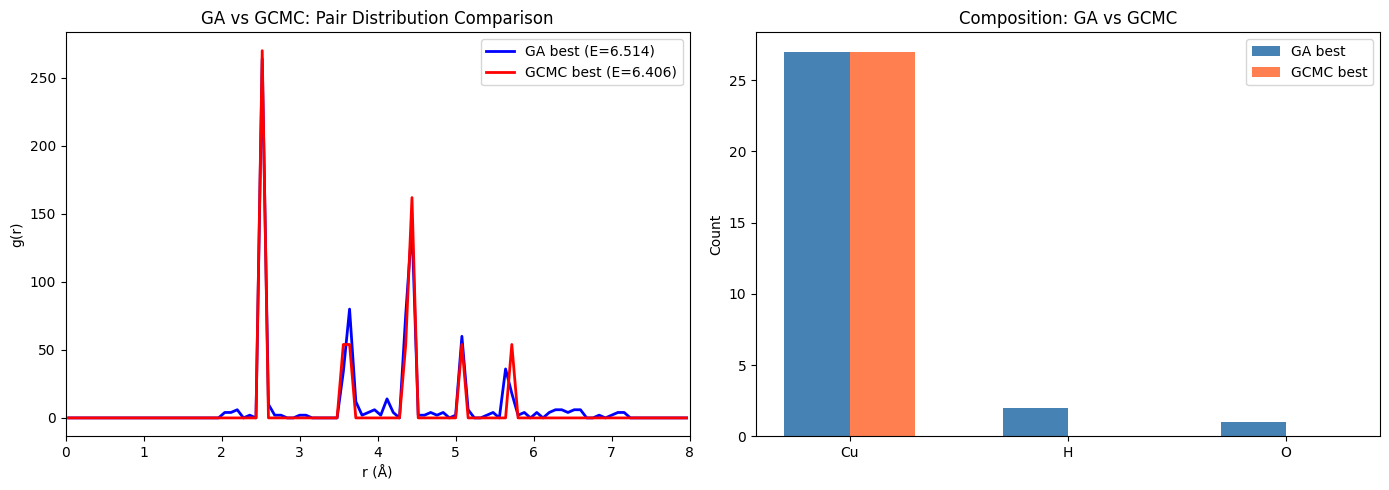

In [16]:
# Compare GA best vs GCMC best
ga_best = candidates[np.argmin(energies)]
gcmc_best = best_atoms

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

r1, g1 = pair_distribution(ga_best, active_only=False)
r2, g2 = pair_distribution(gcmc_best, active_only=False)

axes[0].plot(r1, g1, "b-", lw=2, label=f"GA best (E={min(energies):.3f})")
axes[0].plot(r2, g2, "r-", lw=2, label=f"GCMC best (E={best_energy:.3f})")
axes[0].set_xlabel("r (Å)")
axes[0].set_ylabel("g(r)")
axes[0].set_title("GA vs GCMC: Pair Distribution Comparison")
axes[0].legend()
axes[0].set_xlim(0, 8)

# Composition comparison
from collections import Counter
ga_comp = Counter(ga_best.get_chemical_symbols())
gcmc_comp = Counter(gcmc_best.get_chemical_symbols())
all_elements = sorted(set(list(ga_comp.keys()) + list(gcmc_comp.keys())))

x = np.arange(len(all_elements))
axes[1].bar(x - 0.15, [ga_comp.get(e, 0) for e in all_elements], 0.3, label="GA best", color="steelblue")
axes[1].bar(x + 0.15, [gcmc_comp.get(e, 0) for e in all_elements], 0.3, label="GCMC best", color="coral")
axes[1].set_xticks(x)
axes[1].set_xticklabels(all_elements)
axes[1].set_ylabel("Count")
axes[1].set_title("Composition: GA vs GCMC")
axes[1].legend()

fp_dist = fingerprint_distance(ga_best, gcmc_best)
print(f"Fingerprint distance between GA and GCMC best: {fp_dist:.4f}")

plt.tight_layout()
plt.show()

## 8. Visualize Structures

View the best structures found by each method, side by side.

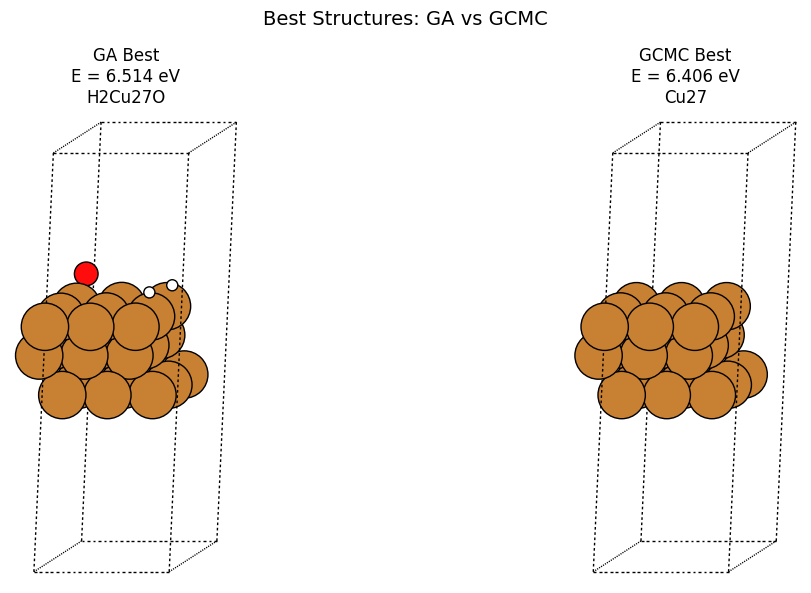

In [17]:
# Visualize GA best and GCMC best side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_atoms(ga_best, axes[0], rotation="-75x,10y,0z")
axes[0].set_title(f"GA Best\nE = {min(energies):.3f} eV\n{ga_best.get_chemical_formula()}")

plot_atoms(gcmc_best, axes[1], rotation="-75x,10y,0z")
axes[1].set_title(f"GCMC Best\nE = {best_energy:.3f} eV\n{gcmc_best.get_chemical_formula()}")

plt.suptitle("Best Structures: GA vs GCMC", fontsize=14)
plt.tight_layout()
plt.show()

Best overall structure: Cu27 (E = 6.4057 eV)

Adsorbate atoms (tag > 0):
  Atom 18 (Cu): CN=9, neighbors=['Cu', 'Cu', 'Cu', 'Cu', 'Cu', 'Cu', 'Cu', 'Cu', 'Cu']
  Atom 19 (Cu): CN=9, neighbors=['Cu', 'Cu', 'Cu', 'Cu', 'Cu', 'Cu', 'Cu', 'Cu', 'Cu']
  Atom 20 (Cu): CN=9, neighbors=['Cu', 'Cu', 'Cu', 'Cu', 'Cu', 'Cu', 'Cu', 'Cu', 'Cu']
  Atom 21 (Cu): CN=9, neighbors=['Cu', 'Cu', 'Cu', 'Cu', 'Cu', 'Cu', 'Cu', 'Cu', 'Cu']
  Atom 22 (Cu): CN=9, neighbors=['Cu', 'Cu', 'Cu', 'Cu', 'Cu', 'Cu', 'Cu', 'Cu', 'Cu']
  Atom 23 (Cu): CN=9, neighbors=['Cu', 'Cu', 'Cu', 'Cu', 'Cu', 'Cu', 'Cu', 'Cu', 'Cu']
  Atom 24 (Cu): CN=9, neighbors=['Cu', 'Cu', 'Cu', 'Cu', 'Cu', 'Cu', 'Cu', 'Cu', 'Cu']
  Atom 25 (Cu): CN=9, neighbors=['Cu', 'Cu', 'Cu', 'Cu', 'Cu', 'Cu', 'Cu', 'Cu', 'Cu']
  Atom 26 (Cu): CN=9, neighbors=['Cu', 'Cu', 'Cu', 'Cu', 'Cu', 'Cu', 'Cu', 'Cu', 'Cu']


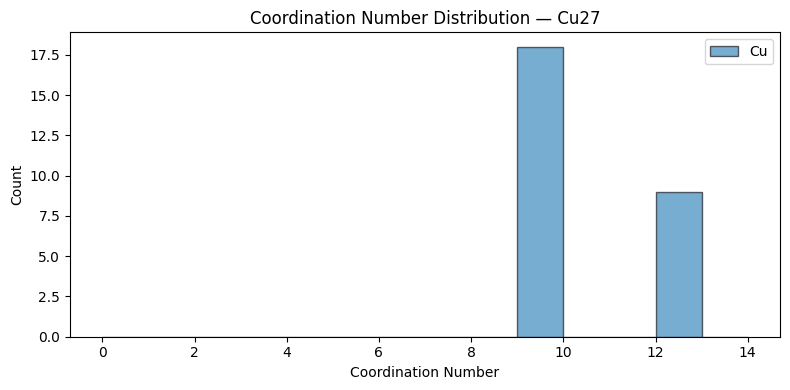

In [18]:
# Bond analysis of the best structure
best_struct = ga_best if min(energies) < best_energy else gcmc_best
best_e = min(min(energies), best_energy)

bm = get_bond_matrix(best_struct)
coord_numbers = bm.sum(axis=1)
symbols = best_struct.get_chemical_symbols()
tags = best_struct.get_tags()

print(f"Best overall structure: {best_struct.get_chemical_formula()} (E = {best_e:.4f} eV)")
print(f"\nAdsorbate atoms (tag > 0):")
for i, (sym, tag, cn) in enumerate(zip(symbols, tags, coord_numbers)):
    if tag > 0:
        neighbors = [symbols[j] for j in range(len(bm)) if bm[i, j]]
        print(f"  Atom {i} ({sym}): CN={cn}, neighbors={neighbors}")

# Coordination number distribution
fig, ax = plt.subplots(figsize=(8, 4))
unique_sym = sorted(set(symbols))
for sym in unique_sym:
    cns = [coord_numbers[i] for i in range(len(symbols)) if symbols[i] == sym]
    ax.hist(cns, bins=range(0, 15), alpha=0.6, label=sym, edgecolor="black")
ax.set_xlabel("Coordination Number")
ax.set_ylabel("Count")
ax.set_title(f"Coordination Number Distribution — {best_struct.get_chemical_formula()}")
ax.legend()
plt.tight_layout()
plt.show()

## Summary

In this tutorial we demonstrated:

| Step | What We Did | Key Classes |
|------|-----------|-------------|
| 1 | Built a Cu(111) slab with tags | `SlabAtoms`, `fcc111` |
| 2 | Defined search space and adsorbates | `BoxRegion`, `MolecularBlock`, `generate_blmin` |
| 3 | Created an energy evaluator | `ASECalculatorEvaluator` (EMT) |
| 4 | Ran GA to find low-energy structures | `StartGenerator`, `GARunner` |
| 5 | Ran GCMC with variable adsorbate count | `GCEnsemble`, `InsertMove`, `DeleteMove` |
| 6 | Analyzed and compared results | `StructureAnalyzer`, `TrajectoryAnalyzer` |
| 7 | Examined bonding topology | `get_bond_matrix`, `pair_distribution` |

### Next Steps
- Replace EMT with `MACEEvaluator` for realistic calculations
- Use `GARunner` / `GCMCRunner` for automated workflows with checkpointing
- Try `GOFEERunner` for GPR-accelerated search
- See the full API documentation at `docs/_build/html/index.html`